In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [82]:
df = pd.read_csv(r'E:\Rnw\algorithms\Superviced learning\pr4\message.csv')

df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [83]:
df.shape

(5200, 16)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

In [85]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [86]:
df = df.dropna()

In [87]:
print(pd.DataFrame(X).isnull().sum())

message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
hour_of_day                0
day_of_week                0
dtype: int64


In [88]:
df.shape

(4832, 16)

In [89]:
X = df.drop(columns=[
    "message_id",
    "message_text",
    "timestamp",
    "spam_label"
])

y = df["spam_label"]


In [90]:
X.head()


,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0
1,73,12,0,0,0,0,0,16.6,207.0,0.0,21,2
2,67,13,0,0,0,0,1,25.7,418.0,6.0,13,5
3,64,13,0,4,0,0,1,48.8,276.0,5.0,23,2
4,84,14,0,0,0,0,1,33.0,683.0,7.0,11,5


In [91]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: spam_label, dtype: int64

In [92]:
from sklearn.preprocessing import StandardScaler

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 1.0
Testing Accuracy  : 1.0


In [116]:
# Check class balance
print(df["spam_label"].value_counts())

# Check duplicate rows
print(df.duplicated().sum())

# Check duplicate feature rows
print(df.drop(columns=["spam_label"]).duplicated().sum())

spam_label
0    3931
1     901
Name: count, dtype: int64
0
0


In [117]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X_scaled,
    y,
    cv=5
)

print(scores)
print("Mean CV Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0


In [95]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [96]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

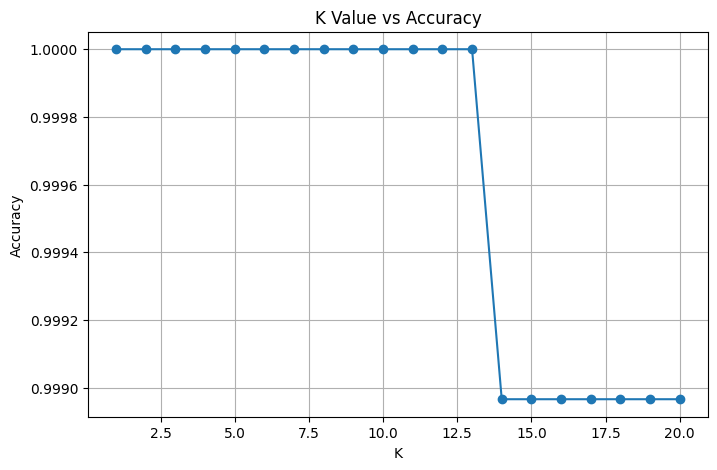

In [98]:
accuracy=[]

for k in range(1,21):
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)

    accuracy.append(accuracy_score(y_test,pred))

plt.figure(figsize=(8,5))
plt.plot(range(1,21),accuracy,marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.grid()
plt.show()

In [99]:
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

train_pred = knn.predict(X_train)
test_pred = knn.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 1.0
Testing Accuracy  : 1.0


In [100]:
metrics=["euclidean","manhattan","minkowski"]

for m in metrics:

    model=KNeighborsClassifier(
        n_neighbors=5,
        metric=m
    )

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    print(m)
    print("Accuracy:",
          accuracy_score(y_test,pred))
    print()
    

euclidean
Accuracy: 1.0

manhattan
Accuracy: 1.0

minkowski
Accuracy: 1.0



In [101]:
misclassified = X_test[knn_pred != y_test]

print("Total Misclassified :",len(misclassified))

Total Misclassified : 0


In [102]:
svm_linear=SVC(kernel="linear")

svm_linear.fit(X_train,y_train)

svm_linear_pred=svm_linear.predict(X_test)

In [103]:
svm_rbf=SVC(kernel="rbf")

svm_rbf.fit(X_train,y_train)

svm_rbf_pred=svm_rbf.predict(X_test)

In [104]:
print("Support Vectors")

print(svm_linear.support_vectors_.shape)

Support Vectors
(11, 12)


In [105]:
print("KNN Accuracy")

print(accuracy_score(y_test,knn_pred))

print()

print("SVM Accuracy")

print(accuracy_score(y_test,svm_linear_pred))

KNN Accuracy
1.0

SVM Accuracy
1.0


In [106]:
nb=GaussianNB()

nb.fit(X_train,y_train)

nb_pred=nb.predict(X_test)

In [107]:
print("Bayes Theorem")

print("P(A|B)=P(B|A)*P(A)/P(B)")

Bayes Theorem
P(A|B)=P(B|A)*P(A)/P(B)


In [108]:
print(nb.predict(X_test[:10]))

[1 0 1 0 0 0 0 0 0 0]


In [109]:
print(classification_report(
    y_test,
    knn_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



In [110]:
print(classification_report(
    y_test,
    svm_linear_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



In [111]:
print(classification_report(
    y_test,
    nb_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



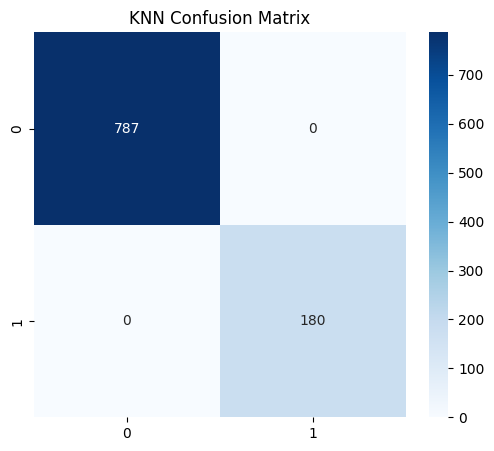

In [112]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test,knn_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.show()

In [113]:
results=pd.DataFrame({

    "Model":[
        "KNN",
        "Linear SVM",
        "Naive Bayes"
    ],

    "Accuracy":[
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,svm_linear_pred),
        accuracy_score(y_test,nb_pred)
    ],

    "Precision":[
        precision_score(y_test,knn_pred),
        precision_score(y_test,svm_linear_pred),
        precision_score(y_test,nb_pred)
    ],

    "Recall":[
        recall_score(y_test,knn_pred),
        recall_score(y_test,svm_linear_pred),
        recall_score(y_test,nb_pred)
    ],

    "F1 Score":[
        f1_score(y_test,knn_pred),
        f1_score(y_test,svm_linear_pred),
        f1_score(y_test,nb_pred)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,Linear SVM,1.0,1.0,1.0,1.0
2,Naive Bayes,1.0,1.0,1.0,1.0


In [114]:
print("Highest Accuracy")

print(results.loc[
    results["Accuracy"].idxmax()
])

print()

print("Highest Precision")

print(results.loc[
    results["Precision"].idxmax()
])

print()

print("Highest Recall")

print(results.loc[
    results["Recall"].idxmax()
])

Highest Accuracy
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 0, dtype: object

Highest Precision
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 0, dtype: object

Highest Recall
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 0, dtype: object


KNN
- Easy to understand
- Sensitive to K value
- Slow for large datasets

SVM
- Excellent accuracy
- Works well in high-dimensional data
- Computationally expensive

Naive Bayes
- Very fast
- Handles large datasets
- Assumes feature independence


Conclusion

1. KNN is simple but depends heavily on K.
2. SVM generally provides the best classification accuracy.
3. Naive Bayes is the fastest classifier and performs well when independence assumptions hold.
4. For spam detection, SVM is usually recommended due to its strong generalization performance, while Naive Bayes is a good choice when computational efficiency is important.